# Lecture 08, Notebook 07: Analytic 6-Agent OLG — DEQN (Exogenous Sampling)

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §5.2 (the 6-agent analytic Krueger–Kübler OLG); §5.3 (DEQN mapping); §5.4 (KKT)  
**Notebook role:** core  
**Author:** Simon Scheidegger

---

This notebook solves the six-age overlapping-generations model of Krueger and Kübler (2004): log utility, stochastic Cobb–Douglas production, four i.i.d. TFP/depreciation aggregate states, and a closed-form age-specific savings rate that the trained policy can be validated against.

The notebook mirrors the structure of the IRBC and benchmark-OLG notebooks: parameters, augmented state, neural-network policy transform, residual / loss construction, training-data generation, mini-batch training, out-of-sample residual tables, policy-stability checks, and validation against the closed-form savings rates.

In this notebook the training cloud is **drawn exogenously** from broad feasible boxes: every segment is an independent feasible state cloud, with no feedback from the current policy. The complementary persistent-simulation companion (`lecture_08_08_OLG_Analytic_DEQN_persistent.ipynb`) trains on simulated trajectories under the current policy. Both expose a `RUN_MODE = "smoke" / "teaching" / "production"` switch (mirrored by the in-notebook `MODE` variable); the default `SAMPLING_MODE` for this notebook is `"exogenous"`.

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

In [11]:
SAMPLING_MODE = "exogenous"

# ============================================================
# Imports, random seeds, and main switches
# ============================================================
import math
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.size"] = 12

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Training-budget switch
# ------------------------------------------------------------
# smoke      : quick code check
# teaching   : classroom/laptop run
# production : paper-style scale; intended for GPU/HPC runs
MODE = RUN_MODE                   # mirrors the run-mode switch in the second cell

if MODE == "smoke":
    NUM_SEGMENTS = 25
    N_TRAJECTORIES = 16
    SIMULATION_LENGTH = 16
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 5
    EVAL_TRACKS = 16
    EVAL_BURN_IN = 16
    EVAL_LENGTH = 32
    HIDDEN_UNITS_1 = 64
    HIDDEN_UNITS_2 = 32
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=3e-4, batch_size=128),
    ]
elif MODE == "teaching":
    NUM_SEGMENTS = 501
    N_TRAJECTORIES = 32
    SIMULATION_LENGTH = 32
    PASSES_PER_SEGMENT = 2
    MONITOR_EVERY = 10
    EVAL_TRACKS = 32
    EVAL_BURN_IN = 64
    EVAL_LENGTH = 128
    HIDDEN_UNITS_1 = 100
    HIDDEN_UNITS_2 = 50
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=1e-4, batch_size=512),
    ]
elif MODE == "production":
    # Appendix A.8 of the DEQN paper uses two hidden layers with 100 and 50
    # ReLU units, 12,800 states per episode, 20 epochs per episode, and a
    # long training run.  This preset keeps that scale.
    NUM_SEGMENTS = 10_000
    N_TRAJECTORIES = 100
    SIMULATION_LENGTH = 128
    PASSES_PER_SEGMENT = 20
    MONITOR_EVERY = 100
    EVAL_TRACKS = 128
    EVAL_BURN_IN = 256
    EVAL_LENGTH = 256
    HIDDEN_UNITS_1 = 100
    HIDDEN_UNITS_2 = 50
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=1e-5, batch_size=640),
    ]
else:
    raise ValueError(f"Unknown MODE: {MODE}")

STATES_PER_SEGMENT = N_TRAJECTORIES * SIMULATION_LENGTH
SHUFFLE_STATES_WITHIN_SEGMENT = True
OPTIMIZER_NAME = "Adam"
CLIP_NORM = 10.0

# Relative Euler residuals are dimensionless consumption wedges.  The penalty
# terms should remain inactive after the first few training iterations.
EULER_WEIGHT = 1.0
PENALTY_WEIGHT = 10.0

# Monitoring on a fixed holdout cloud, as in the IRBC notebook.  The network has
# no calendar-time input, so same-state repeatability is exact; the useful check
# is whether the learned function is still moving across SGD updates.
TIME_INVARIANCE_ANCHOR_STATES = 256 if MODE == "smoke" else 2048
TIME_INVARIANCE_TOL_RMS = 1.0e-3
TIME_INVARIANCE_TOL_MAX = 1.0e-2

print(f"TensorFlow version: {tf.__version__}")
print(f"SAMPLING_MODE = {SAMPLING_MODE}")
print(f"MODE = {MODE}")
print(f"states per segment = {STATES_PER_SEGMENT}")
print(f"hidden units = ({HIDDEN_UNITS_1}, {HIDDEN_UNITS_2})")


TensorFlow version: 2.19.0
SAMPLING_MODE = exogenous
MODE = teaching
states per segment = 1024
hidden units = (100, 50)


## 1. Economic parameters

---

The Krueger–Kübler (2004) calibration: $A = 6$ overlapping agents, log utility, Cobb–Douglas production with capital share $\alpha = 0.3$, discount factor $\beta = 0.7$, only agent~1 supplies labor, and four i.i.d. aggregate states combining TFP $\eta \in \{0.95, 1.05\}$ and depreciation $\delta \in \{0.5, 0.9\}$ with equal probability ($\pi_{ss'} = 0.25$). Under these choices the model has a closed-form age-specific savings rate (see §8).


=== Analytic OLG parameters ===
N_AGES = 6, raw state dim = 7, feature dim = 40
policy dim = 5
BETA = 0.7, GAMMA = 1.0, ALPHA = 0.3
TFP: [0.95 1.05 0.95 1.05]
Depreciation: [0.5 0.5 0.9 0.9]
Transition matrix PI:
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Labor endowment: [1. 0. 0. 0. 0. 0.]
Closed-form savings rates used for diagnostics:
  age 1: 0.659999
  age 2: 0.639393
  age 3: 0.605211
  age 4: 0.543379
  age 5: 0.411765


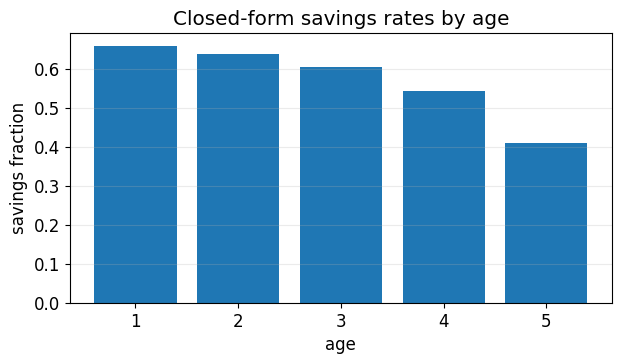

In [12]:
# ============================================================
# Analytic OLG parameters
# ============================================================
N_AGES = 6
NUM_SHOCKS = 4
AGES = np.arange(1, N_AGES + 1)

# Preferences and technology.  The closed-form benchmark requires log utility.
BETA = 0.70
GAMMA = 1.0
ALPHA = 0.30

# Aggregate shocks: order is
#   0 = low TFP, low depreciation
#   1 = high TFP, low depreciation
#   2 = low TFP, high depreciation
#   3 = high TFP, high depreciation
TFP = np.array([0.95, 1.05, 0.95, 1.05], dtype=np.float32)
DEPR = np.array([0.50, 0.50, 0.90, 0.90], dtype=np.float32)
PI = np.ones((NUM_SHOCKS, NUM_SHOCKS), dtype=np.float32) / NUM_SHOCKS
PI_CUM = np.cumsum(PI, axis=1)

# Labor endowment: only the newborn cohort supplies labor.  Aggregate labor is 1.
LABOR = np.zeros(N_AGES, dtype=np.float32)
LABOR[0] = 1.0
L_TOTAL = float(np.sum(LABOR))

# Closed-form savings rates.  These are used only for diagnostics, never in the
# training loss or in the construction of simulated training states.
BETA_VEC = BETA * (1.0 - BETA ** (N_AGES - 1 - np.arange(N_AGES - 1))) / (
    1.0 - BETA ** (N_AGES - np.arange(N_AGES - 1))
)

# Tensor constants
TFP_TF = tf.constant(TFP.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
DEPR_TF = tf.constant(DEPR.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
PI_TF = tf.constant(PI, dtype=tf.float32)
LABOR_TF = tf.constant(LABOR.reshape(1, N_AGES), dtype=tf.float32)
L_TOTAL_TF = tf.constant(L_TOTAL, dtype=tf.float32)
BETA_VEC_TF = tf.constant(BETA_VEC.reshape(1, N_AGES - 1), dtype=tf.float32)

RAW_STATE_DIM = 1 + N_AGES       # [z, k_1,...,k_N]
FEATURE_DIM = 1 + NUM_SHOCKS + 2 + 5 + 4 * N_AGES + NUM_SHOCKS
N_CHOICES = N_AGES - 1
POLICY_DIM = N_CHOICES           # savings a^1,...,a^{N-1}

print("=== Analytic OLG parameters ===")
print(f"N_AGES = {N_AGES}, raw state dim = {RAW_STATE_DIM}, feature dim = {FEATURE_DIM}")
print(f"policy dim = {POLICY_DIM}")
print(f"BETA = {BETA}, GAMMA = {GAMMA}, ALPHA = {ALPHA}")
print("TFP:", TFP)
print("Depreciation:", DEPR)
print("Transition matrix PI:")
print(PI)
print("Labor endowment:", LABOR)
print("Closed-form savings rates used for diagnostics:")
for age, rate in zip(AGES[:-1], BETA_VEC):
    print(f"  age {age}: {rate:.6f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(AGES[:-1], BETA_VEC)
ax.set_title("Closed-form savings rates by age")
ax.set_xlabel("age")
ax.set_ylabel("savings fraction")
ax.grid(alpha=0.25, axis="y")
plt.show()


## 2. State representation and augmented network inputs

---

The minimal state is the cohort capital vector together with the aggregate shock indicator ($1 + A = 7$ numbers for $A = 6$). To make learning easier we feed the network an **extended state** that pre-computes aggregates, per-agent income blocks, and the shock-transition probabilities — `FEATURE_DIM` numbers in all: the shock index and its one-hot ($1 + 4$), the shock values $(\eta_t, \delta_t)$, five aggregates $(K_t, L_t, r_t, w_t, Y_t)$, four per-agent blocks (capital $k_t^h$ and the income components $\mathrm{fw}_t^h, \mathrm{linc}_t^h, \mathrm{inc}_t^h$, $4A$ numbers), and the transition-probability row $\boldsymbol{\pi}(z_t)$ ($4$ numbers):

$$
  \dim(\mathbf{s}_t) = \underbrace{1 + 4 + 2 + 5}_{12\text{ aggregate}} + \underbrace{4A}_{\text{per-agent}} + \underbrace{4}_{\boldsymbol{\pi}(z_t)} = 16 + 4A,
$$

which is $40$ for the analytic model ($A = 6$). The augmentation is pure feature engineering: the equilibrium is unchanged, only the network input is enriched.

In [13]:
# ============================================================
# State representation, firm prices, and network features
# ============================================================
EPS = 1.0e-8
CONSUMPTION_FLOOR = 1.0e-8

# Feature scales.  These are numerical normalizations, not equilibrium targets.
ASSET_SCALE = 1.0
AGG_K_SCALE = max(1.0, 0.4 * N_AGES)
AGG_L_SCALE = max(1.0, L_TOTAL)
PRICE_SCALE = 1.0
OUTPUT_SCALE = 1.0

# Broad feasible boxes for exogenous training states and initial simulation
# heads.  These draws deliberately do not use a lifecycle shape, steady state,
# or the closed-form solution.
EXOGENOUS_K_LOW = 0.005
EXOGENOUS_K_HIGH = 1.00
INITIAL_K_LOW = 0.005
INITIAL_K_HIGH = 1.00

EMERGENCY_REPAIR_BAD_STATES = True
SIM_REPAIR_AGG_K_MIN = 1.0e-8
SIM_REPAIR_AGG_K_MAX = 1.0e3
SIM_REPAIR_ABS_K_MAX = 1.0e3


def unpack_state(states):
    """Return integer shock indices and capital holdings."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z = tf.cast(tf.round(states[:, 0]), tf.int32)
    k = states[:, 1:1 + N_AGES]
    return z, k


def assemble_states_tf(z, k):
    """Assemble a TensorFlow raw state array."""
    z = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    return tf.concat([z, tf.cast(k, tf.float32)], axis=1)


def assemble_states_np(z, k):
    """Assemble a NumPy raw state array."""
    return np.concatenate([
        np.asarray(z, dtype=np.float32).reshape(-1, 1),
        np.asarray(k, dtype=np.float32),
    ], axis=1).astype(np.float32)


def firm_prices_from_components(K, eta, depr):
    """Return r, w, and aggregate output for the analytic OLG production function."""
    K_safe = tf.maximum(tf.cast(K, tf.float32), EPS)
    eta = tf.cast(eta, tf.float32)
    depr = tf.cast(depr, tf.float32)
    L = tf.ones_like(K_safe) * L_TOTAL_TF
    r = ALPHA * eta * tf.pow(K_safe, ALPHA - 1.0) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr)
    w = (1.0 - ALPHA) * eta * tf.pow(K_safe, ALPHA) * tf.pow(L, -ALPHA)
    Y = eta * tf.pow(K_safe, ALPHA) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr) * K_safe
    return r, w, Y


def state_prices(states):
    """Prices and aggregates implied by the raw state."""
    z, k = unpack_state(states)
    eta = tf.gather(TFP_TF, z)
    depr = tf.gather(DEPR_TF, z)
    K = tf.reduce_sum(k, axis=1, keepdims=True)
    r, w, Y = firm_prices_from_components(K, eta, depr)
    return K, r, w, Y, eta, depr


def current_income(states):
    """Income before current savings choices: r k + w l."""
    _, k = unpack_state(states)
    K, r, w, Y, eta, depr = state_prices(states)
    financial_income = r * k
    labor_income = w * LABOR_TF
    income = financial_income + labor_income
    return income, labor_income, financial_income, K, r, w, Y, eta, depr


def network_features(states):
    """Build the augmented input used by the neural net.

    The raw state remains [z, k].  The augmentation supplies the same type of
    redundant economic information used in the larger OLG notebook: shock
    indicators, transition probabilities, prices, capital, financial income,
    labor income, and total income.
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z, k = unpack_state(states)
    income, labor_income, financial_income, K, r, w, Y, eta, depr = current_income(states)
    z_float = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    one_hot_z = tf.one_hot(z, NUM_SHOCKS, dtype=tf.float32)
    transition_row = tf.gather(PI_TF, z)
    features = tf.concat([
        z_float / max(1.0, NUM_SHOCKS - 1.0),
        one_hot_z,
        eta,
        depr,
        K / AGG_K_SCALE,
        tf.ones_like(K) * (L_TOTAL / AGG_L_SCALE),
        r / PRICE_SCALE,
        w / PRICE_SCALE,
        Y / OUTPUT_SCALE,
        k / ASSET_SCALE,
        financial_income / ASSET_SCALE,
        labor_income / ASSET_SCALE,
        income / ASSET_SCALE,
        transition_row,
    ], axis=1)
    return features


# Quick dimension check on random raw states.
_X_dim_check = np.zeros((3, RAW_STATE_DIM), dtype=np.float32)
_X_dim_check[:, 0] = np.arange(3) % NUM_SHOCKS
_X_dim_check[:, 1:1 + N_AGES] = 0.1
_X_dim_check[:, 1] = 0.0
assert int(network_features(_X_dim_check).shape[1]) == FEATURE_DIM
print(f"network feature dimension check passed: {FEATURE_DIM}")


network feature dimension check passed: 40


## 3. Neural network and policy transformation

---

The policy network is an MLP from the 40-dimensional augmented state to the savings of cohorts $1,\ldots,A-1$ (cohort $A$ saves nothing),

$$
  \mathcal{N}_\theta(\mathbf{s}_t) \;\longrightarrow\; \bigl(\hat a_t^1, \hat a_t^2, \ldots, \hat a_t^{A-1}\bigr), \qquad \hat a_t^h = k_{t+1}^{h+1}.
$$

The output head is a **sigmoid savings-fraction transform**: the raw network output is squashed to a fraction $\hat\beta_h \in (0, 1)$ of current income, and savings are then $\hat a_t^h = \hat\beta_h \cdot \mathrm{inc}_t^h$ (the saving of cohort $h$ at $t$; the newborn enters with $k_{t+1}^1 = 0$). This guarantees $\hat a_t^h \ge 0$ *and* current consumption $c_t^h = (1 - \hat\beta_h)\,\mathrm{inc}_t^h \ge 0$ by construction (so the soft non-negativity penalties below are dead backstops), and it matches the closed-form solution's structure ("save a fixed fraction $\beta_h$ of income"). Aggregate next-period capital is recovered as $K_{t+1} = \sum_{h=1}^{A-1} \hat a_t^h = \sum_{h=2}^{A} k_{t+1}^h$, so capital-market clearing also holds by construction. Borrowing constraints are non-binding everywhere on the ergodic set under the Krueger–Kübler calibration, so no Lagrange multipliers appear in the policy output.

In [14]:
# ============================================================
# Neural network and economically admissible policy transform
# ============================================================
# The last layer is initialized at zero.  The policy transform maps raw outputs
# to savings fractions in (0,1), so current consumption is positive whenever
# income is positive.  This is a numerical feasibility transform, not a target
# policy: the closed-form savings rates are not used in training.
MIN_SAVING_FRACTION = 1.0e-6
MAX_SAVING_FRACTION = 1.0 - 1.0e-5
POLICY_LOGIT_SHIFT = 0.0


def build_network():
    return keras.Sequential([
        keras.layers.Input(shape=(FEATURE_DIM,)),
        keras.layers.Dense(HIDDEN_UNITS_1, activation="relu"),
        keras.layers.Dense(HIDDEN_UNITS_2, activation="relu"),
        keras.layers.Dense(
            POLICY_DIM,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
        ),
    ], name="OLG_DEQN_analytic")


def policy(states, model):
    """Map raw states to admissible savings policies.

    Returns
    -------
    a             : savings for ages 1,...,N-1
    savings_frac  : a divided by current income, in (0,1)
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    raw = model(network_features(states))
    income, _, _, _, _, _, _, _, _ = current_income(states)
    income_choice = tf.maximum(income[:, :N_CHOICES], 0.0)
    savings_frac = MIN_SAVING_FRACTION + (MAX_SAVING_FRACTION - MIN_SAVING_FRACTION) * tf.nn.sigmoid(
        raw + POLICY_LOGIT_SHIFT
    )
    a = savings_frac * income_choice
    return a, savings_frac


def analytical_policy(states):
    """Closed-form solution for diagnostics only."""
    income, _, _, _, _, _, _, _, _ = current_income(states)
    return income[:, :N_CHOICES] * BETA_VEC_TF


def policy_fingerprint(states, model):
    """Dimensionless policy vector for policy-drift diagnostics."""
    a, frac = policy(states, model)
    return tf.concat([tf.math.log1p(a), frac], axis=1)


def relative_policy_drift(previous, current):
    previous = np.asarray(previous, dtype=np.float64)
    current = np.asarray(current, dtype=np.float64)
    diff = current - previous
    scale = 1.0 + np.sqrt(np.mean(previous ** 2))
    return float(np.sqrt(np.mean(diff ** 2)) / scale), float(np.max(np.abs(diff)) / scale)


def policy_error_against_analytic(states, model):
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    a_deqn, frac = policy(states, model)
    a_exact = analytical_policy(states)
    rel_error = (a_deqn - a_exact) / tf.maximum(tf.abs(a_exact), CONSUMPTION_FLOOR)
    frac_error = frac - BETA_VEC_TF
    return rel_error, frac_error, a_deqn, a_exact, frac


model_check = build_network()
a0, frac0 = policy(_X_dim_check, model_check)
print("Initial-policy smoke check")
print(f"  mean savings fraction = {float(tf.reduce_mean(frac0)):.4f}")
print(f"  min savings           = {float(tf.reduce_min(a0)):.4e}")
print(f"  max savings           = {float(tf.reduce_max(a0)):.4e}")


Initial-policy smoke check
  mean savings fraction = 0.5000
  min savings           = 2.8149e-02
  max savings           = 2.9850e-01


## 4. Residuals and loss

---

For each cohort $h = 1, \ldots, A-1$ the relative Euler residual is

$$
  \mathrm{EulerErr}_h(\mathbf{s}_t) \;=\; 
  \frac{\beta\, \mathbb{E}_t\!\left[\, u'(c_{t+1}^{h+1})\, \bigl(R_{t+1} + 1 - \delta_{t+1}\bigr)\,\right]}
       {u'(c_t^h)} \;-\; 1,
$$

with $u(c) = \log c$ in this calibration. Reporting is done in *relative* form so that a value of $10^{-3}$ corresponds directly to a 0.1% Euler-equation wedge. The total loss is

$$
  \ell_\theta \;=\; \frac{1}{N_s}\sum_{i=1}^{N_s} \sum_{h=1}^{A-1} \bigl(\mathrm{EulerErr}_h(\mathbf{s}_i)\bigr)^2,
$$

with the conditional expectation evaluated by direct summation over the four discrete shock states. No market-clearing term is needed — capital-market clearing is satisfied by construction (see §3).


In [15]:
# ============================================================
# Residuals and loss
# ============================================================

def marginal_utility(c):
    return tf.pow(tf.maximum(c, CONSUMPTION_FLOOR), -GAMMA)


def inverse_marginal_utility(x):
    return tf.pow(tf.maximum(x, CONSUMPTION_FLOOR), -1.0 / GAMMA)


def consumption_from_savings(states, a):
    """Budget constraint for all ages, including a_N=0."""
    income, labor_income, financial_income, K, r, w, Y, eta, depr = current_income(states)
    a_all = tf.concat([a, tf.zeros([tf.shape(states)[0], 1], dtype=tf.float32)], axis=1)
    c_raw = income - a_all
    return c_raw, income, K, r, w, Y


@tf.function
def compute_residuals(states, model):
    """Return the DEQN loss and residual components on a state batch."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    m = tf.shape(states)[0]
    z, _ = unpack_state(states)
    probs_next = tf.gather(PI_TF, z)

    a, frac = policy(states, model)
    c_raw, income, K, r, w, Y = consumption_from_savings(states, a)
    c = tf.maximum(c_raw, CONSUMPTION_FLOOR)

    k_next = tf.concat([tf.zeros([m, 1], dtype=tf.float32), a], axis=1)
    K_next_raw = tf.reduce_sum(k_next, axis=1, keepdims=True)

    expected_marginal = tf.zeros([m, N_CHOICES], dtype=tf.float32)
    future_c_raw = []

    for shock in range(NUM_SHOCKS):
        z_next = tf.ones([m], dtype=tf.float32) * float(shock)
        x_next = assemble_states_tf(z_next, k_next)
        a_next, _ = policy(x_next, model)
        c_next_raw, _, _, r_next, _, _ = consumption_from_savings(x_next, a_next)
        c_next = tf.maximum(c_next_raw, CONSUMPTION_FLOOR)

        prob = probs_next[:, shock:shock + 1]
        expected_marginal += prob * r_next * marginal_utility(c_next[:, 1:N_AGES])
        future_c_raw.append(c_next_raw)

    euler = inverse_marginal_utility(BETA * expected_marginal) / c[:, 0:N_CHOICES] - 1.0

    all_c_raw = tf.concat([c_raw] + future_c_raw, axis=1)
    neg_c_penalty = tf.maximum(-all_c_raw, 0.0) / (1.0 + tf.abs(all_c_raw))
    bad_K_penalty = tf.maximum(-K_next_raw, 0.0) / (1.0 + tf.abs(K_next_raw))

    loss = (
        EULER_WEIGHT * tf.reduce_mean(tf.square(euler))
        + PENALTY_WEIGHT * (
            tf.reduce_mean(tf.square(neg_c_penalty)) + tf.reduce_mean(tf.square(bad_K_penalty))
        )
    )

    components = {
        "euler_capital": euler,
        "c_raw": c_raw,
        "c": c,
        "a": a,
        "savings_fraction": frac,
        "K": K,
        "Y": Y,
        "negative_consumption_penalty": neg_c_penalty,
        "bad_K_penalty": bad_K_penalty,
    }
    return loss, components


_loss_check, _comp_check = compute_residuals(_X_dim_check, model_check)
print(f"initial residual finite: {np.isfinite(float(_loss_check.numpy()))}, loss = {float(_loss_check.numpy()):.3e}")


initial residual finite: True, loss = 1.020e-01


## Training-data construction

In this version, training states are drawn exogenously from broad feasible boxes. This is useful for checking the residual code without the additional feedback created by simulation. The state clouds are deliberately not centered on a deterministic steady state, a lifecycle profile, or the closed-form policy.


In [16]:
# ============================================================
# Training-data construction
# ============================================================

def _sample_feasible_box(n, k_low, k_high, local_rng):
    """Random feasible states from broad boxes; no lifecycle or steady-state prior."""
    z = local_rng.integers(0, NUM_SHOCKS, size=n).astype(np.float32)
    log_k = local_rng.uniform(np.log(k_low), np.log(k_high), size=(n, N_AGES)).astype(np.float32)
    k = np.exp(log_k).astype(np.float32)
    k[:, 0] = 0.0
    return assemble_states_np(z, k)


def sample_exogenous_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 1000 + seed_offset)
    return _sample_feasible_box(n, EXOGENOUS_K_LOW, EXOGENOUS_K_HIGH, local_rng)


def sample_feasible_initial_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 2000 + seed_offset)
    return _sample_feasible_box(n, INITIAL_K_LOW, INITIAL_K_HIGH, local_rng)


def draw_next_shocks(z_current):
    z_int = np.asarray(np.round(z_current), dtype=np.int64)
    u = rng.random(len(z_int))
    return np.sum(u[:, None] > PI_CUM[z_int], axis=1).astype(np.float32)


def one_step_transition(states_np, model, z_next_np):
    states_tf = tf.constant(states_np, dtype=tf.float32)
    a, _ = policy(states_tf, model)
    a_np = a.numpy().astype(np.float32)
    k_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), a_np], axis=1)
    return assemble_states_np(z_next_np, k_next)


def one_step_transition_analytic(states_np, z_next_np):
    states_tf = tf.constant(states_np, dtype=tf.float32)
    a_np = analytical_policy(states_tf).numpy().astype(np.float32)
    k_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), a_np], axis=1)
    return assemble_states_np(z_next_np, k_next)


def bad_state_mask(states_np):
    states_np = np.asarray(states_np, dtype=np.float32)
    finite = np.all(np.isfinite(states_np), axis=1)
    z = states_np[:, 0]
    k = states_np[:, 1:1 + N_AGES]
    K = np.sum(k, axis=1)
    mask_good = (
        finite
        & (z >= -0.5) & (z <= NUM_SHOCKS - 0.5)
        & np.all(k >= -1.0e-8, axis=1)
        & (K >= SIM_REPAIR_AGG_K_MIN)
        & (K <= SIM_REPAIR_AGG_K_MAX)
        & np.all(np.abs(k) <= SIM_REPAIR_ABS_K_MAX, axis=1)
    )
    return ~mask_good


def simulate_path(X0, model, n_steps, seed_offset=0, return_time_major=False):
    """Simulate under the current learned policy.

    Initial states are random feasible states from broad boxes, not steady-state
    values, analytical-policy states, or lifecycle profiles.  Emergency repair
    only replaces numerically invalid states by fresh feasible-box draws.
    """
    X = np.asarray(X0, dtype=np.float32).copy()
    n_tracks = X.shape[0]
    path = np.empty((n_steps, n_tracks, RAW_STATE_DIM), dtype=np.float32)
    n_repaired = 0

    for t in range(n_steps):
        path[t] = X
        z_next = draw_next_shocks(X[:, 0])
        X_next = one_step_transition(X, model, z_next)
        if EMERGENCY_REPAIR_BAD_STATES:
            bad = bad_state_mask(X_next)
            if np.any(bad):
                n_bad = int(np.sum(bad))
                X_next[bad] = sample_feasible_initial_states(n_bad, seed_offset=seed_offset + 10_000 + t)
                n_repaired += n_bad
        X = X_next

    if return_time_major:
        return path, X, n_repaired
    return path.reshape(-1, RAW_STATE_DIM), X, n_repaired


def get_training_segment(X_start, model, segment_index):
    if SAMPLING_MODE == "exogenous":
        X = sample_exogenous_states(STATES_PER_SEGMENT, seed_offset=segment_index)
        return X, X_start, 0
    if SAMPLING_MODE == "simulation":
        return simulate_path(X_start, model, SIMULATION_LENGTH, seed_offset=segment_index)
    raise ValueError(f"Unknown SAMPLING_MODE: {SAMPLING_MODE}")


def sample_time_invariance_anchor_states(n):
    return sample_exogenous_states(n, seed_offset=999_001)


X_sampling_check = sample_exogenous_states(5)
print("sample state shape:", X_sampling_check.shape)
print("bad sampled states:", int(np.sum(bad_state_mask(X_sampling_check))))


sample state shape: (5, 7)
bad sampled states: 0


## 5. Mini-batches and training loop

---

A training segment may contain many states; the variables `BATCH_SIZE`, `PASSES_PER_SEGMENT`, and `OPTIMIZER_NAME` determine how the optimizer uses these states. The segment-continuation logic is intentionally explicit:

```python
X_segment, X_end = get_training_segment(X_start, model)
... optimizer updates on X_segment ...
X_start = X_end
```


In [17]:
# ============================================================
# Mini-batches, optimizer, and training loop
# ============================================================

def make_optimizer(learning_rate):
    if OPTIMIZER_NAME == "Adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "RMSprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "SGD":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0)
    raise ValueError(f"Unknown optimizer: {OPTIMIZER_NAME}")


def hyperparameters_for_segment(segment):
    for item in TRAINING_SCHEDULE:
        if segment < int(item["until"]):
            return float(item["learning_rate"]), int(item["batch_size"])
    item = TRAINING_SCHEDULE[-1]
    return float(item["learning_rate"]), int(item["batch_size"])


def set_optimizer_learning_rate(optimizer, learning_rate):
    try:
        optimizer.learning_rate.assign(learning_rate)
    except Exception:
        optimizer.learning_rate = learning_rate


def iterate_minibatches(X, batch_size):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    if SHUFFLE_STATES_WITHIN_SEGMENT:
        order = rng.permutation(n)
    else:
        order = np.arange(n)
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        if len(idx) > 0:
            yield tf.constant(X[idx], dtype=tf.float32)


@tf.function
def train_step(X_batch, model, optimizer):
    with tf.GradientTape() as tape:
        loss, _ = compute_residuals(X_batch, model)
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, model.trainable_variables)]
    if CLIP_NORM is not None:
        grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train_on_segment_states(X_segment, model, optimizer, batch_size):
    losses = []
    for _ in range(PASSES_PER_SEGMENT):
        for X_batch in iterate_minibatches(X_segment, batch_size):
            losses.append(float(train_step(X_batch, model, optimizer).numpy()))
    return float(np.mean(losses)), len(losses)


def summarize_monitor_components(X, components, model):
    rel_policy, frac_policy, _, _, _ = policy_error_against_analytic(tf.constant(X, dtype=tf.float32), model)
    return {
        "mean_abs_euler_capital": float(tf.reduce_mean(tf.abs(components["euler_capital"])).numpy()),
        "mean_abs_policy_error": float(tf.reduce_mean(tf.abs(rel_policy)).numpy()),
        "max_abs_policy_error": float(tf.reduce_max(tf.abs(rel_policy)).numpy()),
        "mean_abs_fraction_error": float(tf.reduce_mean(tf.abs(frac_policy)).numpy()),
        "share_negative_consumption": float(tf.reduce_mean(tf.cast(components["c_raw"] <= 0.0, tf.float32)).numpy()),
    }


model = build_network()
learning_rate_0, _batch_size_0 = hyperparameters_for_segment(0)
optimizer = make_optimizer(learning_rate_0)

X_start = sample_feasible_initial_states(N_TRAJECTORIES)
X_anchor = sample_time_invariance_anchor_states(TIME_INVARIANCE_ANCHOR_STATES)
anchor_fingerprint_previous = policy_fingerprint(tf.constant(X_anchor), model).numpy()

history = {
    "segment": [],
    "loss": [],
    "train_loss": [],
    "mean_abs_euler_capital": [],
    "mean_abs_policy_error": [],
    "max_abs_policy_error": [],
    "mean_abs_fraction_error": [],
    "share_negative_consumption": [],
    "policy_drift_rms": [],
    "policy_drift_max": [],
    "K_min": [],
    "K_max": [],
    "repairs": [],
    "n_updates": [],
}

print("Starting training")
print(f"  segments: {NUM_SEGMENTS}")
print(f"  states per segment: {STATES_PER_SEGMENT}")
print(f"  passes per segment: {PASSES_PER_SEGMENT}")
start_time = time.time()
last_segment = None

for segment in range(NUM_SEGMENTS):
    learning_rate, batch_size = hyperparameters_for_segment(segment)
    set_optimizer_learning_rate(optimizer, learning_rate)

    X_segment, X_end, n_repaired = get_training_segment(X_start, model, segment)
    train_loss, n_updates = train_on_segment_states(X_segment, model, optimizer, batch_size)
    last_segment = X_segment

    if SAMPLING_MODE == "simulation":
        X_start = X_end

    if segment % MONITOR_EVERY == 0 or segment == NUM_SEGMENTS - 1:
        loss_now, components_now = compute_residuals(tf.constant(X_segment), model)
        monitor = summarize_monitor_components(X_segment, components_now, model)
        K_np = X_segment[:, 1:1 + N_AGES].sum(axis=1)
        anchor_fingerprint_current = policy_fingerprint(tf.constant(X_anchor), model).numpy()
        drift_rms, drift_max = relative_policy_drift(anchor_fingerprint_previous, anchor_fingerprint_current)
        anchor_fingerprint_previous = anchor_fingerprint_current

        history["segment"].append(int(segment))
        history["loss"].append(float(loss_now.numpy()))
        history["train_loss"].append(float(train_loss))
        for key, value in monitor.items():
            history[key].append(value)
        history["policy_drift_rms"].append(drift_rms)
        history["policy_drift_max"].append(drift_max)
        history["K_min"].append(float(np.min(K_np)))
        history["K_max"].append(float(np.max(K_np)))
        history["repairs"].append(int(n_repaired))
        history["n_updates"].append(int(n_updates))

        elapsed = time.time() - start_time
        print(
            f"seg {segment:6d} | log10(loss)={np.log10(max(history['loss'][-1], 1e-30)): .3f} | "
            f"Euler={monitor['mean_abs_euler_capital']:.3e} | "
            f"policy err={monitor['mean_abs_policy_error']:.3e} | "
            f"K=[{history['K_min'][-1]:.3f},{history['K_max'][-1]:.3f}] | "
            f"drift={drift_rms:.2e} | repairs={n_repaired} | {elapsed:.1f}s"
        )

print(f"Training finished in {time.time() - start_time:.1f} seconds")


Starting training
  segments: 501
  states per segment: 1024
  passes per segment: 2
seg      0 | log10(loss)=-0.998 | Euler=3.120e-01 | policy err=1.843e-01 | K=[0.040,3.558] | drift=4.25e-04 | repairs=0 | 5.8s
seg     10 | log10(loss)=-1.111 | Euler=2.750e-01 | policy err=1.617e-01 | K=[0.044,3.181] | drift=6.74e-03 | repairs=0 | 6.1s
seg     20 | log10(loss)=-1.398 | Euler=1.940e-01 | policy err=1.131e-01 | K=[0.075,2.796] | drift=1.50e-02 | repairs=0 | 6.3s
seg     30 | log10(loss)=-2.014 | Euler=8.336e-02 | policy err=5.081e-02 | K=[0.044,2.705] | drift=2.20e-02 | repairs=0 | 6.6s
seg     40 | log10(loss)=-2.430 | Euler=4.924e-02 | policy err=2.782e-02 | K=[0.056,3.083] | drift=1.31e-02 | repairs=0 | 6.8s
seg     50 | log10(loss)=-2.624 | Euler=3.932e-02 | policy err=2.188e-02 | K=[0.053,4.158] | drift=2.37e-03 | repairs=0 | 7.0s
seg     60 | log10(loss)=-2.826 | Euler=3.051e-02 | policy err=1.664e-02 | K=[0.045,3.199] | drift=2.07e-03 | repairs=0 | 7.3s
seg     70 | log10(loss)=-

## 6. Final diagnostics

---

The final diagnostics report relative Euler residuals on two out-of-sample state clouds — an exogenous test cloud for off-trajectory robustness, and a simulated test cloud for accuracy on the ergodic region induced by the learned policy. Mean and max absolute Euler residuals are dimensionless, so a *mean* of, say, $2 \times 10^{-3}$ corresponds to a 0.2% average wedge.


In [18]:
# ============================================================
# Final diagnostics: residual tables and data-cloud checks
# ============================================================

def _np_abs(x):
    return np.abs(np.asarray(x, dtype=np.float64).reshape(-1))


def stats_row(values, scale=1.0):
    v = scale * _np_abs(values)
    return {
        "mean": float(np.mean(v)),
        "max": float(np.max(v)),
        "p0.1": float(np.quantile(v, 0.001)),
        "p10": float(np.quantile(v, 0.10)),
        "p50": float(np.quantile(v, 0.50)),
        "p90": float(np.quantile(v, 0.90)),
        "p99.9": float(np.quantile(v, 0.999)),
    }


def residual_table(X, model):
    loss, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    rel_policy, frac_policy, _, _, _ = policy_error_against_analytic(tf.constant(X, dtype=tf.float32), model)
    rows = {
        "Rel Ee capital [%]": stats_row(comp["euler_capital"].numpy(), scale=100.0),
        "Policy error vs analytic [%]": stats_row(rel_policy.numpy(), scale=100.0),
        "Savings-fraction error": stats_row(frac_policy.numpy()),
    }
    table = pd.DataFrame(rows).T[["mean", "max", "p0.1", "p10", "p50", "p90", "p99.9"]]
    return float(loss.numpy()), table, comp


def data_cloud_report(label, X, model):
    X = np.asarray(X, dtype=np.float32)
    z = X[:, 0].astype(int)
    k = X[:, 1:1 + N_AGES]
    loss, comp = compute_residuals(tf.constant(X), model)
    c_raw = comp["c_raw"].numpy()
    rel_policy, frac_policy, _, _, _ = policy_error_against_analytic(tf.constant(X, dtype=tf.float32), model)
    print(f"\n{label}")
    print(f"  states                         {X.shape[0]}")
    print(f"  shock counts                   {np.bincount(z, minlength=NUM_SHOCKS)}")
    print(f"  aggregate K range              [{k.sum(axis=1).min():.4f}, {k.sum(axis=1).max():.4f}]")
    print(f"  individual k range             [{k.min():.4f}, {k.max():.4f}]")
    print(f"  consumption range under policy  [{c_raw.min():.4e}, {c_raw.max():.4e}]")
    print(f"  share c<=0 under policy         {np.mean(c_raw <= 0.0):.4%}")
    print(f"  mean abs Euler wedge            {float(tf.reduce_mean(tf.abs(comp['euler_capital'])).numpy()):.3e}")
    print(f"  mean abs policy error           {float(tf.reduce_mean(tf.abs(rel_policy)).numpy()):.3e}")
    print(f"  max abs policy error            {float(tf.reduce_max(tf.abs(rel_policy)).numpy()):.3e}")
    print(f"  loss                            {float(loss.numpy()):.3e}")


def simulated_evaluation_states(model, n_eval_tracks=EVAL_TRACKS, burn_in=EVAL_BURN_IN, eval_length=EVAL_LENGTH):
    X0 = sample_feasible_initial_states(n_eval_tracks, seed_offset=777)
    path, _, n_repaired = simulate_path(X0, model, burn_in + eval_length, seed_offset=888, return_time_major=True)
    if n_repaired > 0:
        print(f"evaluation simulation repaired {n_repaired} numerically invalid states")
    path_eval = path[burn_in:]
    return path_eval.reshape(-1, RAW_STATE_DIM)


N_EVAL_EXOGENOUS = 1024 if MODE == "smoke" else 8192
X_eval_exog = sample_exogenous_states(N_EVAL_EXOGENOUS, seed_offset=54321)
X_eval_sim = simulated_evaluation_states(model)

if last_segment is not None:
    data_cloud_report("Last training segment", last_segment, model)
data_cloud_report("Out-of-sample exogenous state cloud", X_eval_exog, model)
data_cloud_report("Out-of-sample simulated state cloud", X_eval_sim, model)

for label, X in [
    ("Last training segment", last_segment if last_segment is not None else X_eval_exog),
    ("Out-of-sample exogenous states", X_eval_exog),
    ("Out-of-sample simulated states", X_eval_sim),
]:
    loss, table, _ = residual_table(X, model)
    print(f"\n{label}: loss = {loss:.3e}")
    display(table)



Last training segment
  states                         1024
  shock counts                   [254 288 231 251]
  aggregate K range              [0.0491, 2.9689]
  individual k range             [0.0000, 0.9995]
  consumption range under policy  [5.7257e-04, 7.7438e-01]
  share c<=0 under policy         0.0000%
  mean abs Euler wedge            1.119e-03
  mean abs policy error           5.230e-04
  max abs policy error            5.740e-03
  loss                            2.605e-06

Out-of-sample exogenous state cloud
  states                         8192
  shock counts                   [2072 2024 2112 1984]
  aggregate K range              [0.0379, 3.3014]
  individual k range             [0.0000, 0.9998]
  consumption range under policy  [5.0674e-04, 7.7750e-01]
  share c<=0 under policy         0.0000%
  mean abs Euler wedge            1.152e-03
  mean abs policy error           5.396e-04
  max abs policy error            8.554e-03
  loss                            2.766e-06

Out

,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],0.111934,1.806688,2.665162e-04,0.014173,0.082821,0.232679,1.105832
Policy error vs analytic [%],0.052303,0.573983,1.010449e-04,0.006941,0.040381,0.109396,0.380388
Savings-fraction error,0.000303,0.003788,5.435348e-07,0.000039,0.000221,0.000662,0.002338



Out-of-sample exogenous states: loss = 2.766e-06


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],0.115232,2.656877,1.783252e-04,0.014794,0.083601,0.246894,1.124554
Policy error vs analytic [%],0.053961,0.855408,8.291527e-05,0.007307,0.041286,0.115087,0.409648
Savings-fraction error,0.000312,0.005646,5.339980e-07,0.000040,0.000230,0.000684,0.002501



Out-of-sample simulated states: loss = 3.148e-06


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],0.129138,0.497413,1.788139e-04,0.009411,0.074244,0.308075,0.478390
Policy error vs analytic [%],0.059100,0.193097,1.240719e-04,0.007057,0.041001,0.137695,0.187463
Savings-fraction error,0.000340,0.001190,7.152557e-07,0.000039,0.000220,0.000774,0.001141


## 7. Policy-stability checks

---

The architecture has no calendar-time input, so a fixed weight vector defines a stationary recursive policy. The empirical question is whether SGD has stopped moving the policy function. The notebook evaluates the policy on a fixed holdout cloud `X_anchor` after each monitoring interval and reports `policy_drift_rms` and `policy_drift_max`. The run is treated as stable once both fall below `TIME_INVARIANCE_TOL_RMS` and `TIME_INVARIANCE_TOL_MAX`.


In [19]:
# ============================================================
# Policy-stability diagnostics
# ============================================================

def final_time_invariance_report():
    print("\nTime-invariance / policy-stability diagnostic")
    fp_1 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    fp_2 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    same_state_max = float(np.max(np.abs(fp_2 - fp_1)))
    print(f"  same-state repeatability max abs difference = {same_state_max:.3e}")

    if len(history["policy_drift_rms"]) == 0:
        print("  no policy-drift history recorded")
        return
    last_rms = history["policy_drift_rms"][-1]
    last_max = history["policy_drift_max"][-1]
    print(f"  last monitor-to-monitor policy drift, rms = {last_rms:.3e}")
    print(f"  last monitor-to-monitor policy drift, max = {last_max:.3e}")
    print(f"  drift tolerances: rms <= {TIME_INVARIANCE_TOL_RMS:g}, max <= {TIME_INVARIANCE_TOL_MAX:g}")
    if last_rms <= TIME_INVARIANCE_TOL_RMS and last_max <= TIME_INVARIANCE_TOL_MAX:
        print("  PASS: policy drift is small on the fixed holdout cloud.")
    else:
        print("  WARNING: policy is still moving. Train longer or lower the learning rate.")


def fixed_shock_path_report(model, shock=1, n_tracks=16, n_steps=200):
    """Iterate the learned policy under a fixed aggregate shock.

    This is the OLG analogue of the IRBC zero-shock check: not a deterministic
    steady state of the original stochastic economy, but a useful numerical
    sanity check for time-homogeneous policy iteration.
    """
    X = sample_feasible_initial_states(n_tracks, seed_offset=4141)
    distances = []
    for _ in range(n_steps):
        z_next = np.full(n_tracks, shock, dtype=np.float32)
        X_next = one_step_transition(X, model, z_next)
        k = np.maximum(X[:, 2:1 + N_AGES], EPS)      # skip newborn k_1 = 0
        kp = np.maximum(X_next[:, 2:1 + N_AGES], EPS)
        dist_k = np.max(np.abs(np.log(kp / k)))
        distances.append(float(dist_k))
        X = X_next
    print("\nFixed-shock policy-iteration diagnostic")
    print(f"  fixed shock index            {shock}")
    print(f"  final scaled transition dist {distances[-1]:.3e}")
    print(f"  final aggregate K range      [{X[:, 1:1 + N_AGES].sum(axis=1).min():.4f}, {X[:, 1:1 + N_AGES].sum(axis=1).max():.4f}]")
    return np.asarray(distances), X


final_time_invariance_report()
fixed_distances, X_fixed_final = fixed_shock_path_report(model, shock=1)



Time-invariance / policy-stability diagnostic
  same-state repeatability max abs difference = 0.000e+00
  last monitor-to-monitor policy drift, rms = 2.536e-05
  last monitor-to-monitor policy drift, max = 1.490e-04
  drift tolerances: rms <= 0.001, max <= 0.01
  PASS: policy drift is small on the fixed holdout cloud.

Fixed-shock policy-iteration diagnostic
  fixed shock index            1
  final scaled transition dist 0.000e+00
  final aggregate K range      [0.9330, 0.9330]


## 8. Plots and closed-form validation

---

The plots monitor training (loss curve, residuals over segments) and validate the trained policy against the closed-form age-specific savings rates of Krueger and Kübler (2004),

$$
  \beta_h \;=\; \beta \cdot \frac{1 - \beta^{A - h}}
       {1 - \beta^{A - h + 1}},
  \qquad h = 1, \ldots, A - 1.
$$

Under log utility and i.i.d. shocks the optimal policy reduces to $\hat a_t^h = \beta_h \cdot \mathrm{inc}_t^h$: each cohort saves a fixed fraction of total income, regardless of the shock. Comparing the trained network's average savings rate by cohort against $\beta_h$ is the one-line validation that gives this model its pedagogical role.


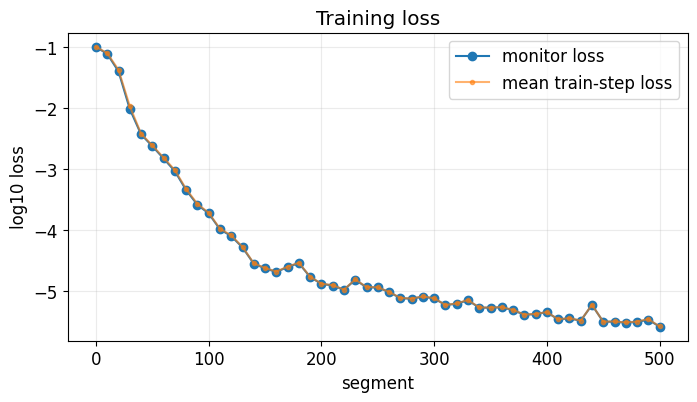

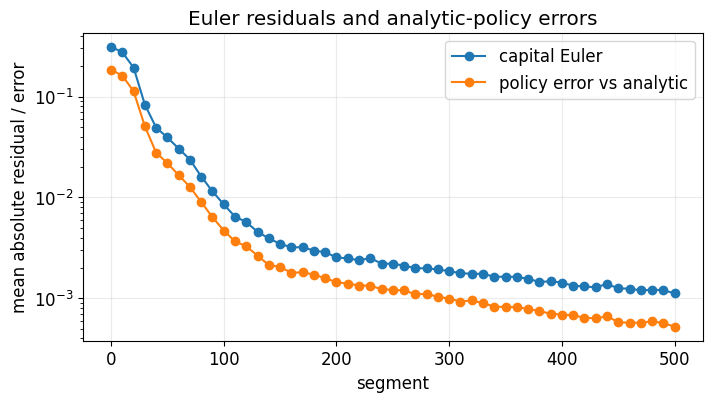

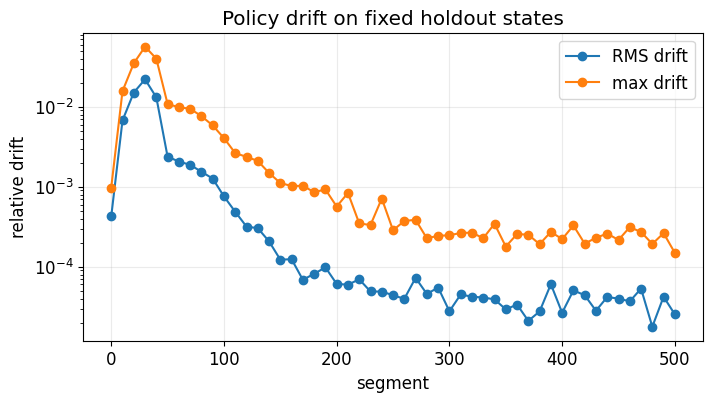

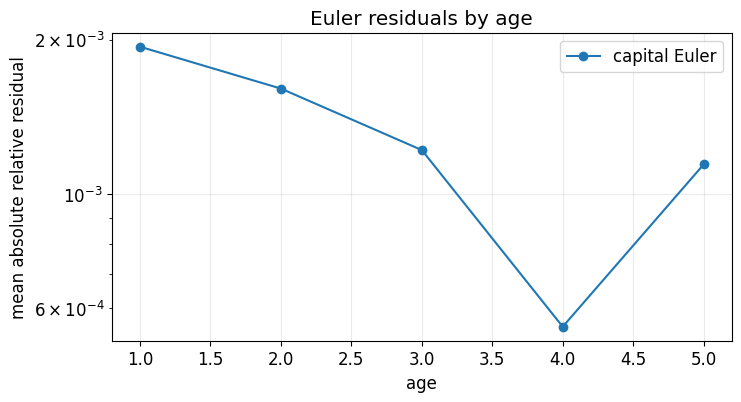

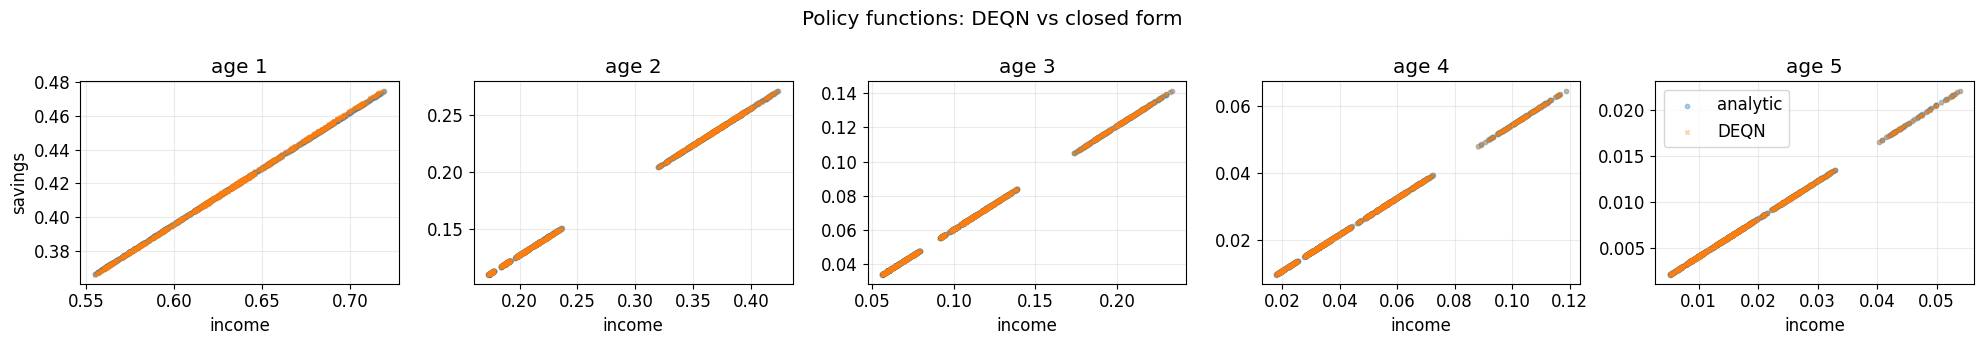

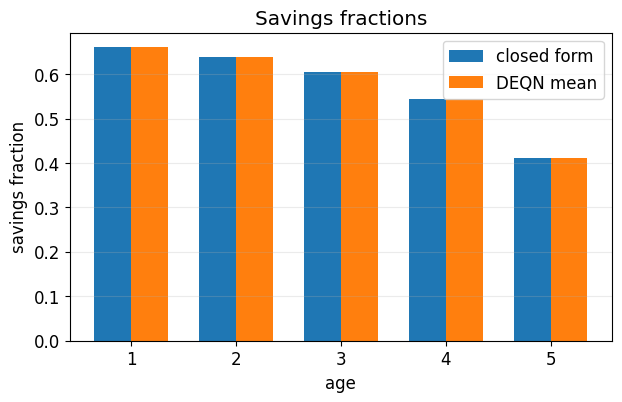

Savings-fraction comparison


,age,closed_form,DEQN_mean,abs_error
0,1,0.659999,0.660004,0.000005
1,2,0.639393,0.639320,0.000073
2,3,0.605211,0.605071,0.000140
3,4,0.543379,0.543216,0.000163
4,5,0.411765,0.411580,0.000185


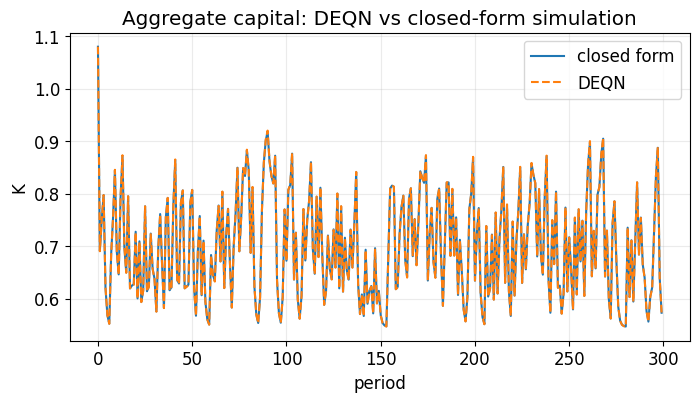

Aggregate-capital path error relative to closed form
  mean = 7.392e-04
  max  = 2.114e-03


In [20]:
# ============================================================
# Simple plots and analytic validation
# ============================================================
if len(history["segment"]) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], np.log10(np.maximum(history["loss"], 1e-30)), marker="o", label="monitor loss")
    ax.plot(history["segment"], np.log10(np.maximum(history["train_loss"], 1e-30)), marker=".", alpha=0.6, label="mean train-step loss")
    ax.set_xlabel("segment")
    ax.set_ylabel("log10 loss")
    ax.set_title("Training loss")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["mean_abs_euler_capital"], marker="o", label="capital Euler")
    ax.plot(history["segment"], history["mean_abs_policy_error"], marker="o", label="policy error vs analytic")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("mean absolute residual / error")
    ax.set_title("Euler residuals and analytic-policy errors")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["policy_drift_rms"], marker="o", label="RMS drift")
    ax.plot(history["segment"], history["policy_drift_max"], marker="o", label="max drift")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("relative drift")
    ax.set_title("Policy drift on fixed holdout states")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def plot_residuals_by_age(X, model, max_states=4096):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 6161).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    _, comp = compute_residuals(tf.constant(X), model)
    e_cap = np.abs(comp["euler_capital"].numpy())
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(AGES[:-1], np.mean(e_cap, axis=0), marker="o", label="capital Euler")
    ax.set_yscale("log")
    ax.set_xlabel("age")
    ax.set_ylabel("mean absolute relative residual")
    ax.set_title("Euler residuals by age")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def plot_policy_against_analytic(X, model, max_states=1024):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 7171).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    X_tf = tf.constant(X, dtype=tf.float32)
    income, _, _, _, _, _, _, _, _ = current_income(X_tf)
    rel_policy, frac_policy, a_deqn, a_exact, frac = policy_error_against_analytic(X_tf, model)
    income_np = income[:, :N_CHOICES].numpy()
    a_deqn_np = a_deqn.numpy()
    a_exact_np = a_exact.numpy()

    fig, axes = plt.subplots(1, N_CHOICES, figsize=(4 * N_CHOICES, 3.5), squeeze=False)
    axes = axes[0]
    for j, ax in enumerate(axes):
        ax.scatter(income_np[:, j], a_exact_np[:, j], s=10, marker="o", alpha=0.35, label="analytic")
        ax.scatter(income_np[:, j], a_deqn_np[:, j], s=8, marker="x", alpha=0.35, label="DEQN")
        ax.set_title(f"age {j + 1}")
        ax.set_xlabel("income")
        if j == 0:
            ax.set_ylabel("savings")
        ax.grid(alpha=0.25)
    axes[-1].legend(loc="best")
    fig.suptitle("Policy functions: DEQN vs closed form")
    plt.tight_layout()
    plt.show()

    mean_frac = np.mean(frac.numpy(), axis=0)
    fig, ax = plt.subplots(figsize=(7, 4))
    width = 0.35
    x = np.arange(1, N_AGES)
    ax.bar(x - width / 2, BETA_VEC, width, label="closed form")
    ax.bar(x + width / 2, mean_frac, width, label="DEQN mean")
    ax.set_xlabel("age")
    ax.set_ylabel("savings fraction")
    ax.set_title("Savings fractions")
    ax.grid(alpha=0.25, axis="y")
    ax.legend()
    plt.show()

    print("Savings-fraction comparison")
    rows = []
    for j in range(N_CHOICES):
        rows.append({
            "age": j + 1,
            "closed_form": BETA_VEC[j],
            "DEQN_mean": mean_frac[j],
            "abs_error": abs(mean_frac[j] - BETA_VEC[j]),
        })
    display(pd.DataFrame(rows))


def compare_exact_and_deqn_dynamics(model, n_tracks=1, n_steps=300, seed_offset=8181):
    local_rng = np.random.default_rng(SEED + seed_offset)
    X_deqn = sample_feasible_initial_states(n_tracks, seed_offset=seed_offset)
    X_exact = X_deqn.copy()
    K_deqn = []
    K_exact = []
    for _ in range(n_steps):
        K_deqn.append(np.sum(X_deqn[:, 1:1 + N_AGES], axis=1))
        K_exact.append(np.sum(X_exact[:, 1:1 + N_AGES], axis=1))
        z_cur = X_deqn[:, 0].astype(int)
        u = local_rng.random(n_tracks)
        z_next = np.sum(u[:, None] > PI_CUM[z_cur], axis=1).astype(np.float32)
        X_deqn = one_step_transition(X_deqn, model, z_next)
        X_exact = one_step_transition_analytic(X_exact, z_next)
    return np.asarray(K_deqn), np.asarray(K_exact)


plot_residuals_by_age(X_eval_sim, model)
plot_policy_against_analytic(X_eval_sim, model)

K_deqn, K_exact = compare_exact_and_deqn_dynamics(model)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_exact[:, 0], label="closed form")
ax.plot(K_deqn[:, 0], linestyle="--", label="DEQN")
ax.set_title("Aggregate capital: DEQN vs closed-form simulation")
ax.set_xlabel("period")
ax.set_ylabel("K")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

rel_K_error = np.abs(K_deqn - K_exact) / np.maximum(np.abs(K_exact), EPS)
print("Aggregate-capital path error relative to closed form")
print(f"  mean = {np.mean(rel_K_error):.3e}")
print(f"  max  = {np.max(rel_K_error):.3e}")


## How to use the notebook

For a quick check, keep `RUN_MODE = "smoke"`. For a classroom run, use `RUN_MODE = "teaching"`. For a paper-style run, use `RUN_MODE = "production"`; this switches to the 100/50 hidden-layer architecture and the episode scale used for the analytic test case in Appendix A.8.

The training loss is still unsupervised: it uses only the Euler equations and feasibility penalties. The closed-form savings rates are reserved for validation tables and plots after training. In the exogenous notebook, every segment is an independent feasible state cloud. In the simulation notebook, each segment is generated by the current policy and the terminal states are used to start the next segment. In both cases, diagnostics evaluate residuals and analytic-policy errors on both exogenous and simulated out-of-sample clouds.
